Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Prerana\OneDrive\Desktop\Ecommerce Revenue Analysis\Ecommerce_Customers.csv")

# Data Overview

In [4]:
#First 5 Rows
df.head()

,Email,Address,Avatar,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
#Shape
df.shape

(500, 8)

In [6]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg Session Length    500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [7]:
# statiscal summary
df.describe()

,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


# Data Cleaning

### 1. Missing Values

In [10]:

df.isnull().sum()


Email                   0
Address                 0
Avatar                  0
Avg Session Length      0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

### Insight

- No missing values found in the dataset.
- The dataset is complete and ready for analysis.

### 2. Duplicate Values

In [11]:
df.duplicated().sum()

np.int64(0)

### Insight

- No duplicate records found.
- Each customer record is unique.

# Exploratory Data Analysis (EDA)

### Distribution of Revenue

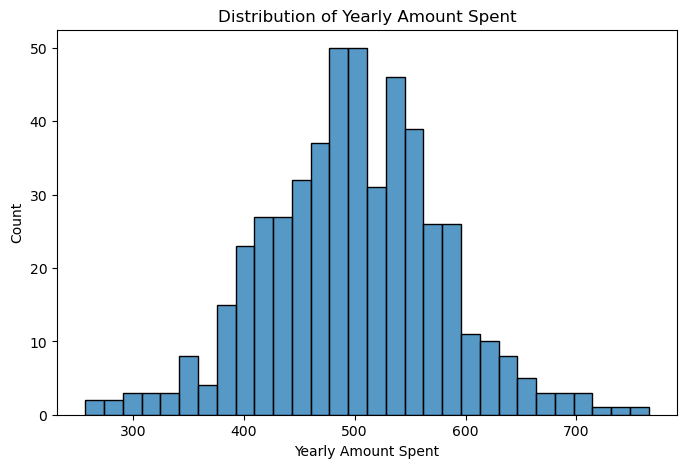

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Yearly Amount Spent"], bins=30)

plt.title("Distribution of Yearly Amount Spent")

plt.show()

### Insight

- Most customers spend between $450 and $600 per year.
- The revenue distribution looks fairly normal.
- Very few customers have extremely high or low spending.

### Business Interpretation

Most customers fall into a similar spending range, showing stable customer purchasing behavior.

### 2. Time on App vs Revenue

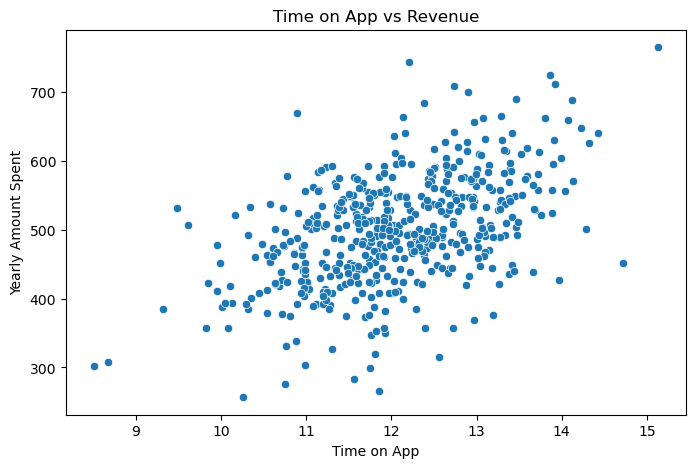

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Time on App",
    y="Yearly Amount Spent"
)

plt.title("Time on App vs Revenue")

plt.show()

### Insight

- Revenue tends to increase as Time on App increases.
- Customers who spend more time on the app generally spend more money.

### Business Interpretation

The mobile app appears to play an important role in generating customer revenue.

### 3 Time on Website vs Revenue

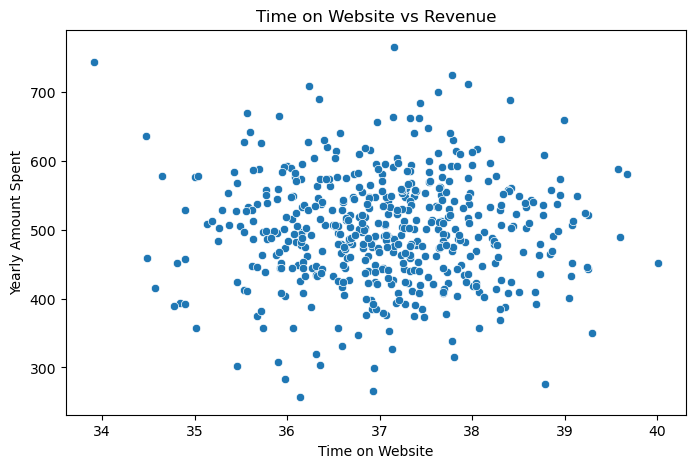

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Time on Website",
    y="Yearly Amount Spent"
)

plt.title("Time on Website vs Revenue")

plt.show()

### Insight

- There is little relationship between Time on Website and Revenue.
- Spending varies widely regardless of website usage.

### Business Interpretation

Website activity alone does not strongly influence customer spending.

### 4 Length of Membership vs Revenue

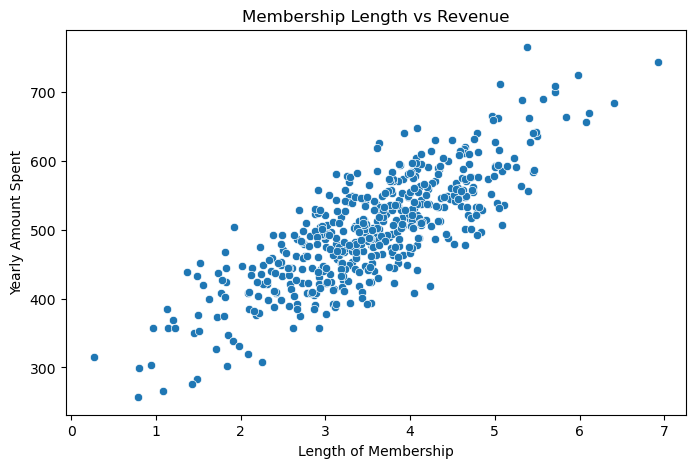

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Length of Membership",
    y="Yearly Amount Spent"
)

plt.title("Membership Length vs Revenue")

plt.show()

### Insight

- Customers with longer memberships spend more money.
- A strong positive relationship is visible.

### Business Interpretation

Customer loyalty appears to be a major factor in increasing revenue.

### 5 Avg Session Length vs Revenue

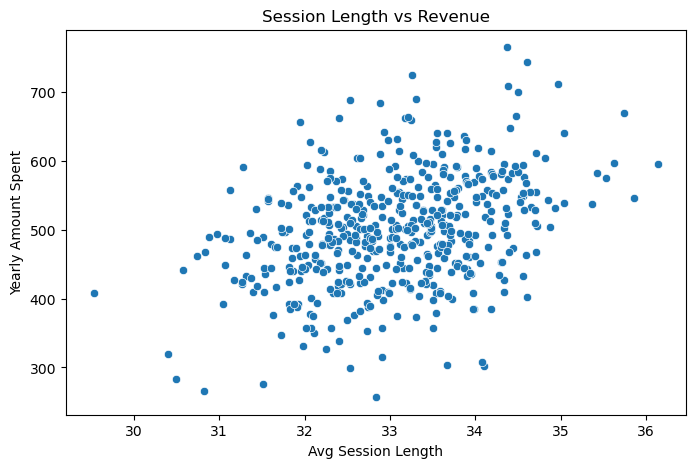

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg Session Length",
    y="Yearly Amount Spent"
)

plt.title("Session Length vs Revenue")

plt.show()

### Insight

- Customers with longer sessions tend to spend more.
- The relationship is positive but not very strong.

### Business Interpretation

Higher customer engagement may contribute to increased spending.

### 6 Correlation Heatmap

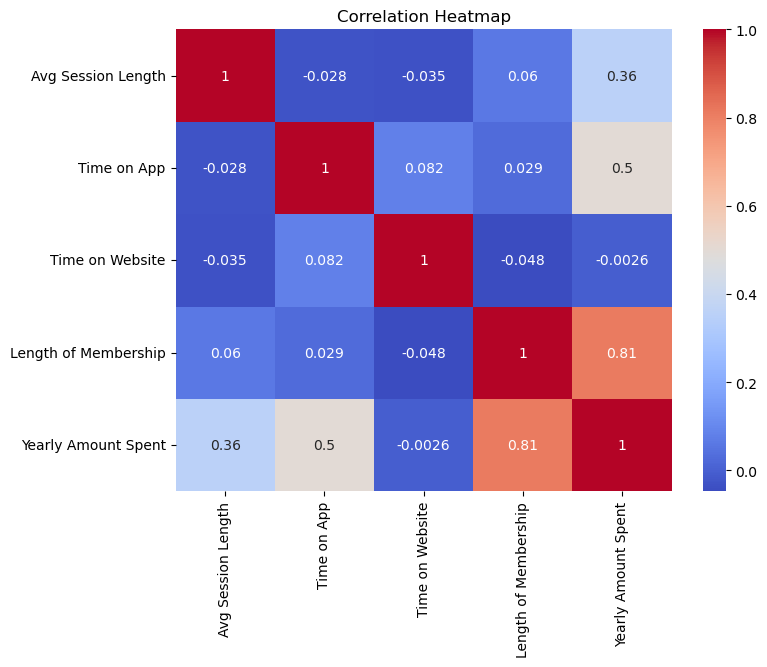

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

- Length of Membership has the strongest correlation with revenue (0.81).
- Time on App shows a moderate positive relationship (0.50).
- Avg Session Length has a moderate positive relationship (0.36).
- Time on Website has almost no relationship with revenue.

### Business Interpretation

Keeping customers for a longer time has the biggest impact on revenue growth.

## Key Findings

- Most customers spend between $450 and $600 annually.
- Time on App positively impacts revenue.
- Time on Website has very little impact on spending.
- Length of Membership is the strongest revenue driver.
- Avg Session Length has a moderate positive relationship with spending.
- Customer retention appears more important than website engagement.

# Linear Regression Model

### Feature Selection

In [19]:
X = df[
[
'Avg Session Length',
'Time on App',
'Time on Website',
'Length of Membership'
]
]

y = df['Yearly Amount Spent']

### Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model Training

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predictions

In [25]:
predictions = lr.predict(X_test)
predictions[:5]

array([402.86230051, 542.53325708, 426.62011918, 501.91386363,
       409.6666551 ])

### Model Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("R² Score :", round(r2,2))

MAE : 8.56
MSE : 109.86
R² Score : 0.98


### Insight

- The model achieved an R² score of 0.98.
- The model explains 98% of the variation in customer spending.
- Prediction errors are very low.
- The model performs extremely well on this dataset.

### Actual vs Predicted Revenue

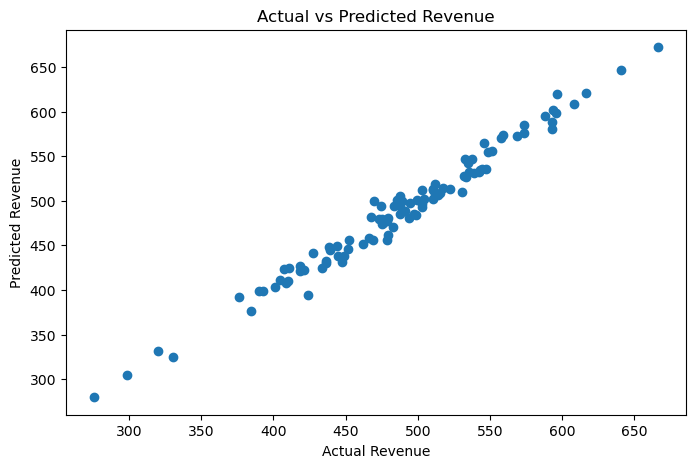

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()

### Insight

- Most points are closely aligned, showing that predicted values are very close to actual values.
- The model is able to estimate customer spending accurately.
- There are very few large prediction errors.

### Business Interpretation

- The model can be used to estimate future customer spending with high accuracy.
- Customer behavior metrics are strong indicators of revenue.

### Feature Importance

In [29]:
coefficients = pd.DataFrame(
    lr.coef_,
    X.columns,
    columns=["Coefficient"]
)

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Coefficient
Length of Membership,61.896829
Time on App,38.785346
Avg Session Length,25.596259
Time on Website,0.310386


### Insight

- Length of Membership has the highest impact on customer spending.
- Time on App is the second most important factor affecting revenue.
- Avg Session Length also contributes positively to spending.
- Time on Website has very little influence on yearly revenue.

### Business Interpretation

- Customers who stay with the company for a longer time tend to spend significantly more.
- Increasing customer retention can have a strong impact on revenue growth.
- Mobile app engagement appears more important than website engagement.

## Conclusion

This project analyzed customer behavior and spending patterns using Python, data visualization, and machine learning.

The analysis showed that Length of Membership is the strongest factor influencing customer spending, followed by Time on App and Avg Session Length. In contrast, Time on Website showed very little impact on revenue.

A Linear Regression model was developed to predict yearly customer spending and achieved an R² score of 0.98, indicating excellent predictive performance.

Overall, the findings suggest that customer retention and mobile app engagement play a key role in increasing revenue and should be a primary focus for business growth strategies.